# Mini-Batch Gradient Descent: Batch Size and Learning Rate Sensitivity

Analyzes how batch size interacts with learning rate stability in PyTorch. Compares full-batch, mini-batch, and stochastic updates on a regression task with loss surface visualization.

In [ ]:
# Import the libraries we need for this lab

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d

In [ ]:
# class for ploting

class plot_error_surfaces(object):

    # Constructor
    def __init__(self, w_range, b_range, X, Y, n_samples = 30, go = True):
        W = np.linspace(-w_range, w_range, n_samples)
        B = np.linspace(-b_range, b_range, n_samples)
        w, b = np.meshgrid(W, B)
        Z = np.zeros((30, 30))
        count1 = 0
        self.y = Y.numpy()
        self.x = X.numpy()
        for w1, b1 in zip(w, b):
            count2 = 0
            for w2, b2 in zip(w1, b1):
                Z[count1, count2] = np.mean((self.y - w2 * self.x + b2) ** 2)
                count2 += 1
            count1 += 1
        self.Z = Z
        self.w = w
        self.b = b
        self.W = []
        self.B = []
        self.LOSS = []
        self.n = 0
        if go == True:
            plt.figure()
            plt.figure(figsize = (7.5, 5))
            plt.axes(projection = '3d').plot_surface(self.w, self.b, self.Z, rstride = 1, cstride = 1, cmap = 'viridis', edgecolor = 'none')
            plt.title('Loss Surface')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.show()
            plt.figure()
            plt.title('Loss Surface Contour')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.contour(self.w, self.b, self.Z)
            plt.show()

    # Setter
    def set_para_loss(self, model, loss):
        self.n = self.n + 1
        self.LOSS.append(loss)
        self.W.append(list(model.parameters())[0].item())
        self.B.append(list(model.parameters())[1].item())

    # Plot diagram
    def final_plot(self):
        ax = plt.axes(projection = '3d')
        ax.plot_wireframe(self.w, self.b, self.Z)
        ax.scatter(self.W, self.B, self.LOSS, c = 'r', marker = 'x', s = 200, alpha = 1)
        plt.figure()
        plt.contour(self.w, self.b, self.Z)
        plt.scatter(self.W, self.B, c = 'r', marker = 'x')
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()

    # Plot diagram
    def plot_ps(self):
        plt.subplot(121)
        plt.ylim()
        plt.plot(self.x, self.y, 'ro', label = "training points")
        plt.plot(self.x, self.W[-1] * self.x + self.B[-1], label = "estimated line")
        plt.xlabel('x')
        plt.ylabel('y')
        plt.ylim((-10, 15))
        plt.title('Data Space Iteration: ' + str(self.n))
        plt.subplot(122)
        plt.contour(self.w, self.b, self.Z)
        plt.scatter(self.W, self.B, c = 'r', marker = 'x')
        plt.title('Loss Surface Contour Iteration' + str(self.n) )
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()

## Make Some Data

In [ ]:
# Import PyTorch library
import torch
torch.manual_seed(9)

In [ ]:
# Generate the data with noise and the line
X = torch.arange(-3, 3, 0.1).view(-1, 1)
f = 1 * X - 1
Y = f + 0.1 * torch.randn(X.size())

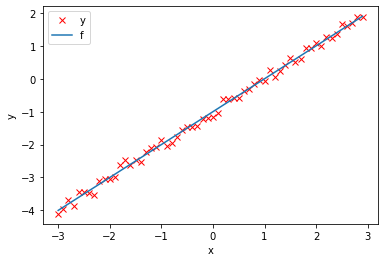

In [ ]:
# Plot the line and the data
plt.plot(X.numpy(), Y.numpy(), 'rx', label = 'y')
plt.plot(X.numpy(), f.numpy(), label = 'f')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()

### Create class Data from Dataset module

In [ ]:
# Create a plot_error_surfaces object.
get_surface = plot_error_surfaces(15, 13, X, Y, 30, go = False)

# Import libraries
from torch.utils.data import Dataset, DataLoader

# Create class Data

class Data(Dataset):

    # Constructor
    def __init__(self):
        self.x = torch.arange(-3, 3, 0.1).view(-1, 1)
        self.y = 1 * X - 1
        self.len = self.x.shape[0]

    # Getter
    def __getitem__(self, index):
        return self.x[index], self.y[index]

    # Get length
    def __len__(self):
        return self.len

## Create the Model and Total Loss Function (Cost)

**Create a `linear regression` class**

In [ ]:
# Create a linear regression model class

from torch import nn, optim

class linear_regression(nn.Module):

    # Constructor
    def __init__(self, input_size, output_size):

        #Inherit from parent
        super(linear_regression, self).__init__()

        self.linear = nn.Linear(input_size, output_size)

    # Prediction
    def forward(self, x):
        yhat = self.linear(x)
        return yhat

### criterion
We will use **PyTorch build-in functions to create a criterion function**; this calculates the total loss or cost

In [ ]:
# Build in cost function
criterion = nn.MSELoss()

### Create Optimizer

In [ ]:
# Create optimizer
model = linear_regression(1,1)
optimizer = optim.SGD(model.parameters(), lr = 0.01)

In [ ]:
list(model.parameters())

[Parameter containing:
 tensor([[0.0044]], requires_grad=True),
 Parameter containing:
 tensor([-0.7514], requires_grad=True)]

![image.png](attachment:image.png)

Similar to the model, **the optimizer has a state dictionary**:

In [ ]:
optimizer.state_dict()

{'state': {},
 'param_groups': [{'lr': 0.01,
   'momentum': 0,
   'dampening': 0,
   'weight_decay': 0,
   'nesterov': False,
   'params': [140655324228016, 140655324228816]}]}

Many of the keys correspond to more advanced optimizers.

Create a `Dataloader` object:

In [ ]:
# Create Data object and DataLoader object
dataset = Data()
trainloader = DataLoader(dataset = dataset, batch_size = 1)

**PyTorch randomly initialises your model parameters**. If we use those parameters, the result will not be very insightful as convergence will be extremely fast. **So we will initialise the parameters such that they will take longer to converge**, i.e. look cool

In [ ]:
# Customize the weight and bias
model.state_dict()['linear.weight'][0] = -15
model.state_dict()['linear.bias'][0] = -10

In [ ]:
# Create plot surface object
get_surface = plot_error_surfaces(15, 13, dataset.x, dataset.y, 30, go = False)

## Train the Model via Batch Gradient Descent
Run 10 epochs of stochastic gradient descent: bug data space is 1 iteration ahead of parameter space.

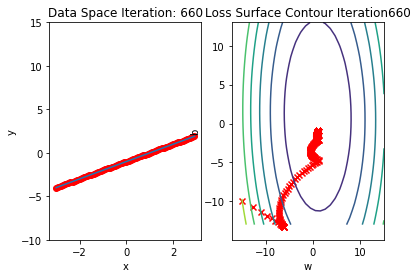

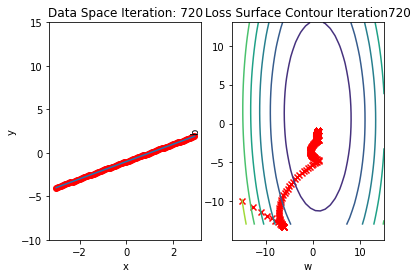

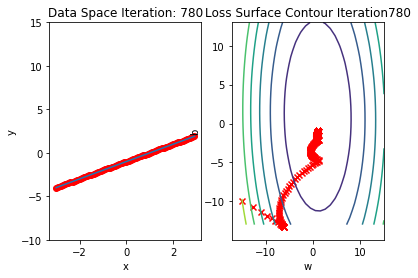

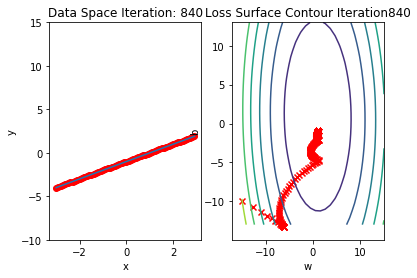

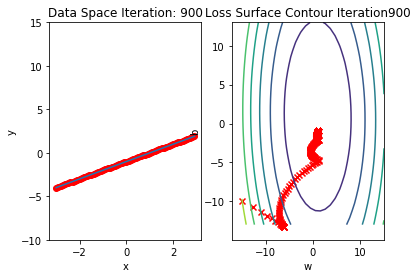

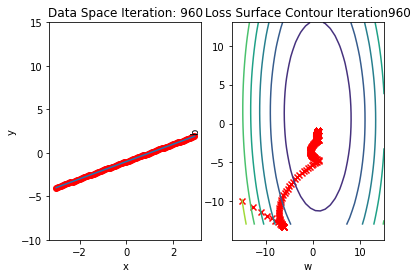

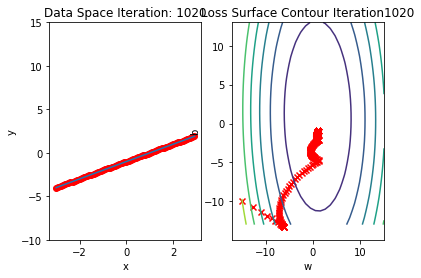

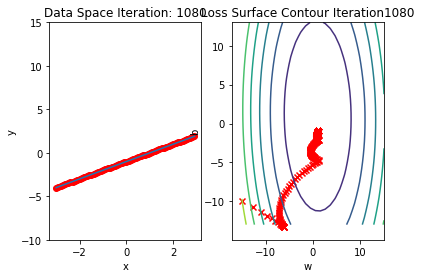

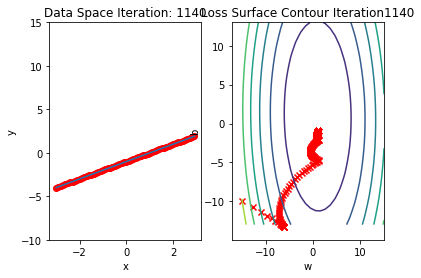

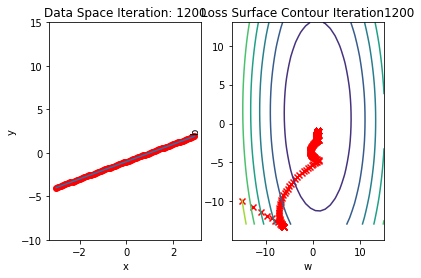

In [ ]:
# Train Model
def train_model_BGD(iter):
    for epoch in range(iter):
        for x,y in trainloader:
            yhat = model(x)
            loss = criterion(yhat, y)
            get_surface.set_para_loss(model, loss.tolist())
            optimizer.zero_grad()
            loss.backward()

            optimizer.step()
        get_surface.plot_ps()


train_model_BGD(10)

In [ ]:
model.state_dict()

OrderedDict([('linear.weight', tensor([[1.0000]])),
             ('linear.bias', tensor([-1.0000]))])

![image.png](attachment:image.png)

![image.png](attachment:image.png)

### Practice
Try to train the model via BGD with lr = 0.1. Use optimizer and the following given variables.

In [ ]:
# Practice: Train the model via BGD using optimizer
model = linear_regression(1,1)
model.state_dict()['linear.weight'][0] = -15
model.state_dict()['linear.bias'][0] = -10
get_surface = plot_error_surfaces(15, 13, dataset.x, dataset.y, 30, go = False)

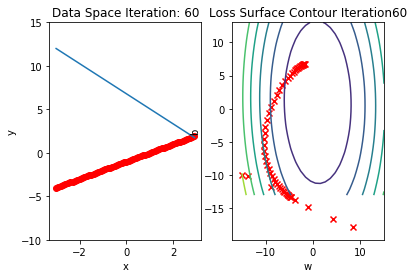

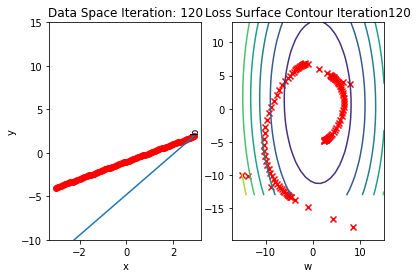

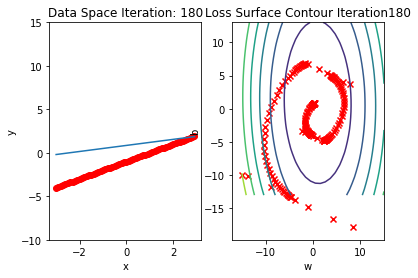

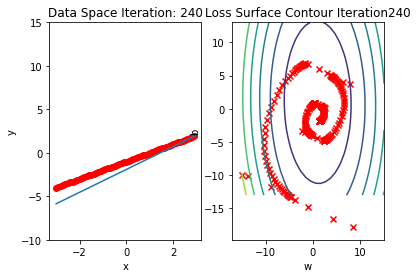

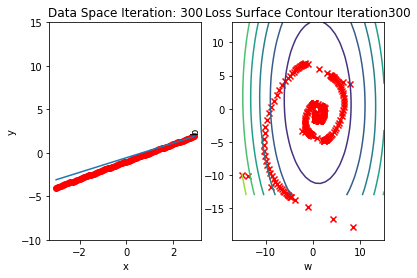

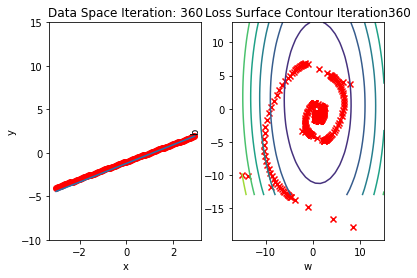

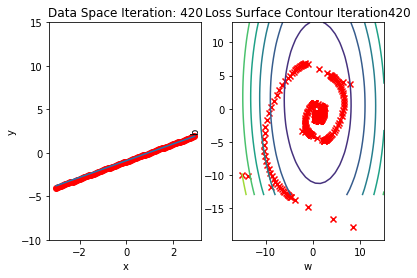

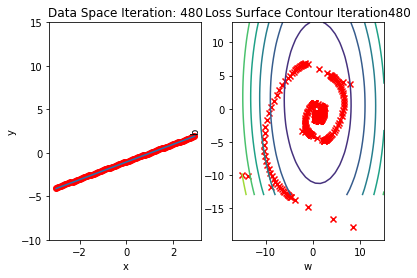

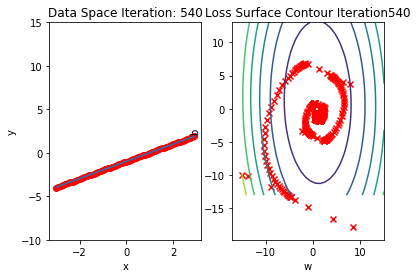

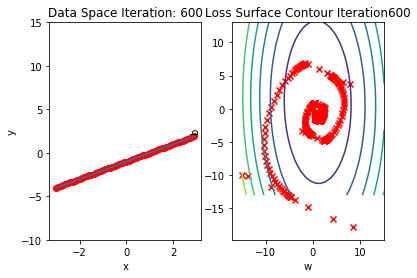

In [ ]:
optimizer = optim.SGD(model.parameters(), lr = 0.1)
trainloader = DataLoader(dataset = dataset, batch_size = 1)

def my_train_model(iter):
    for epoch in range(iter):
        for x,y in trainloader:
            yhat = model(x)
            loss = criterion(yhat, y)
            get_surface.set_para_loss(model, loss.tolist())
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        get_surface.plot_ps()

train_model_BGD(10)